In [135]:
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
spy_df = pd.read_csv("SPY_close_price_5Y.csv")
spy_df['Date'] = pd.to_datetime(spy_df['Date'])
spy_df.head()

,Date,Close
0,2020-11-02,330.20
1,2020-11-03,336.03
2,2020-11-04,343.54
3,2020-11-05,350.24
4,2020-11-06,350.16


In [94]:
# 50 day rolling average
spy_df['50-Day Avg'] = spy_df.rolling(50, on='Date')['Close'].mean()

# 200 day average
spy_df['200-Day Avg'] = spy_df.rolling(200, on='Date')['Close'].mean()

In [95]:
# calculate Golden Cross: 
# A binary field (1/0) that equals 1 only on the exact date when the 50-day average crosses from below the 200-day average; otherwise 0

spy_df['Golden Cross'] = (
    (spy_df['50-Day Avg'] > spy_df['200-Day Avg']) & 
    (spy_df['50-Day Avg'].shift(1) <= spy_df['200-Day Avg'].shift(1))
).astype(int)
spy_df

,Date,Close,50-Day Avg,200-Day Avg,Golden Cross
0,2020-11-02,330.20,NaN,NaN,0
1,2020-11-03,336.03,NaN,NaN,0
2,2020-11-04,343.54,NaN,NaN,0
3,2020-11-05,350.24,NaN,NaN,0
4,2020-11-06,350.16,NaN,NaN,0
...,...,...,...,...,...
1251,2025-10-27,685.24,658.5806,607.44455,0
1252,2025-10-28,687.06,659.4558,607.97740,0
1253,2025-10-29,687.39,660.4074,608.50740,0
1254,2025-10-30,679.83,661.2418,608.99560,0


In [96]:
golden_cross_df = spy_df[spy_df['Golden Cross'] == 1]
golden_cross_df

,Date,Close,50-Day Avg,200-Day Avg,Golden Cross
566,2023-02-02,416.78,394.3504,394.25025,1
1169,2025-07-01,617.65,583.0978,582.04155,1


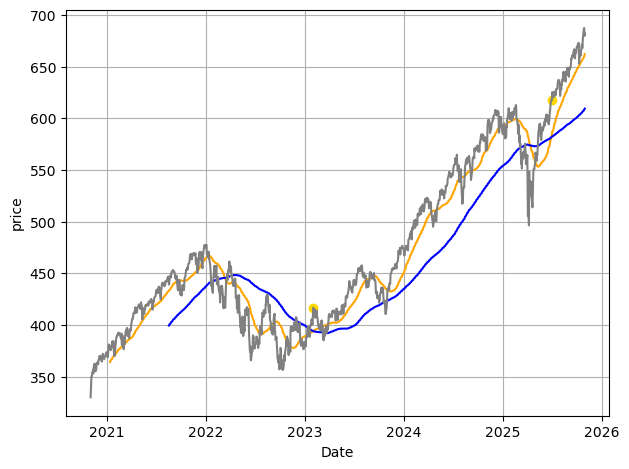

In [134]:
# plot the graph
plt.plot(spy_df['Date'], spy_df['50-Day Avg'], label='50-Day avg', color='orange', linestyle='-')
plt.plot(spy_df['Date'], spy_df['200-Day Avg'], label='200-Day avg', color='blue', linestyle='-')
plt.plot(spy_df['Date'], spy_df['Close'], label='Closing Price', color='grey', linestyle='-')

plt.scatter(golden_cross_df['Date'], golden_cross_df['Close'], marker='o', color='gold')

plt.xlabel('Date')
plt.ylabel('price')
plt.tight_layout()
plt.grid(True)
plt.show()